In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})
import numpy as np
import os
from classy_sz import Class as Class_sz
import tszpower as tsz

/Users/boris/Desktop/tszsbi/tszpower/__init__.py:1: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  from .config import classy_sz
/Users/boris/Desktop/tszsbi/tszenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Using class_sz

In [2]:
allpars = {
    'omega_b': 0.02242,
    'omega_cdm':  0.1193,
    'H0': 67.66,
    'tau_reio': 0.0544,
    'ln10^{10}A_s': 2.972,
    # 'sigma8': 0.81,
    'n_s': 0.9665,
    "cosmo_model": 0, # 1: use mnu-lcdm emulators; 0: use lcdm with fixed neutrino mass
    "B": 1.41,

    'M_min': 1e14*0.6766,
    'M_max': 1e15*0.6766,

    'z_min' : 0.5,
    'z_max' : 3.0,

    "P0GNFW": 8.130,
    "c500": 1.156,
    "gammaGNFW": 0.3292,
    "alphaGNFW": 1.0620,
    "betaGNFW":5.4807,

    'jax' : 0, 
}

In [3]:
precision_params = {
'x_outSZ': 4., # truncate profile beyond x_outSZ*r_s

# 'n_m_pressure_profile' :500, # default: 100, decrease for faster, not used if you use fft
# 'n_z_pressure_profile' :500, # default: 100, decrease for faster, not used if you use fft


'use_fft_for_profiles_transform' : 1, # use fft's or not.
# only used if use_fft_for_profiles_transform set to 1
'N_samp_fftw' :8192,
'x_min_gas_pressure_fftw' : 1e-12,
'x_max_gas_pressure_fftw' : 1e12,


'ndim_redshifts' :100,


'redshift_epsabs': 1.0e-40,
'redshift_epsrel': 0.0001,


'mass_epsabs': 1.0e-40,
'mass_epsrel': 0.0001
}
classy_sz = Class_sz()
classy_sz.set(allpars)
classy_sz.set(precision_params)
classy_sz.set({

'output': 'tSZ_tSZ_1h,tSZ_tSZ_2h',
'skip_input':0,
"ell_min" : 2,
"ell_max" : 1100,
# 'dell': 10.,
'dlogell': 0.1,


'mass_function' : 'T08M500c',
'pressure_profile':'GNFW', # can be Battaglia, Arnaud, etc
'no_spline_in_tinker': 1,
'HMF_prescription_NCDM': 1,
"hm_consistency":0, # this parameter is important at low-ell, should be 1, see discussion in https://arxiv.org/abs/2507.07346
"damping_1h_term": 0, # this parameters control exponential damping at low-ell (see refs in https://arxiv.org/abs/2507.07346)


})
classy_sz.compute_class_szfast()

/Users/boris/Desktop/tszsbi/tszenv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3699: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/boris/Desktop/tszsbi/tszenv/lib/python3.12/site-packages/mcfit/mcfit.py:130: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")


In [4]:
l = np.asarray(classy_sz.cl_sz()['ell'])
cl_yy_1h = np.asarray(classy_sz.cl_sz()['1h'])
cl_yy_2h = np.asarray(classy_sz.cl_sz()['2h'])

In [5]:
cl_yy_1h

array([4.64148019e-07, 5.48928629e-07, 6.50588593e-07, 7.72666059e-07,
       9.19461743e-07, 1.09620529e-06, 1.30925873e-06, 1.56636425e-06,
       1.87694713e-06, 2.25248473e-06, 2.70695741e-06, 3.25739842e-06,
       3.92456576e-06, 4.73376116e-06, 5.71583118e-06, 6.90838840e-06,
       8.35730247e-06, 1.01185204e-05, 1.22602892e-05, 1.48658692e-05,
       1.80368461e-05, 2.18971759e-05, 2.65981215e-05, 3.23242808e-05,
       3.93009444e-05, 4.78030781e-05, 5.81662866e-05, 7.08001931e-05,
       8.62047696e-05, 1.04990261e-04, 1.27901489e-04, 1.55847497e-04,
       1.89937697e-04, 2.31525917e-04, 2.82264074e-04, 3.44167527e-04,
       4.19694592e-04, 5.11843224e-04, 6.24268446e-04, 7.61424790e-04,
       9.28738834e-04, 1.13281777e-03, 1.38170099e-03, 1.68516256e-03,
       2.05507381e-03, 2.50583564e-03, 3.05489157e-03, 3.72333162e-03,
       4.53659728e-03, 5.52529435e-03, 6.72611557e-03, 8.18286756e-03,
       9.94757801e-03, 1.20777344e-02, 1.46569421e-02, 1.77567828e-02,
      

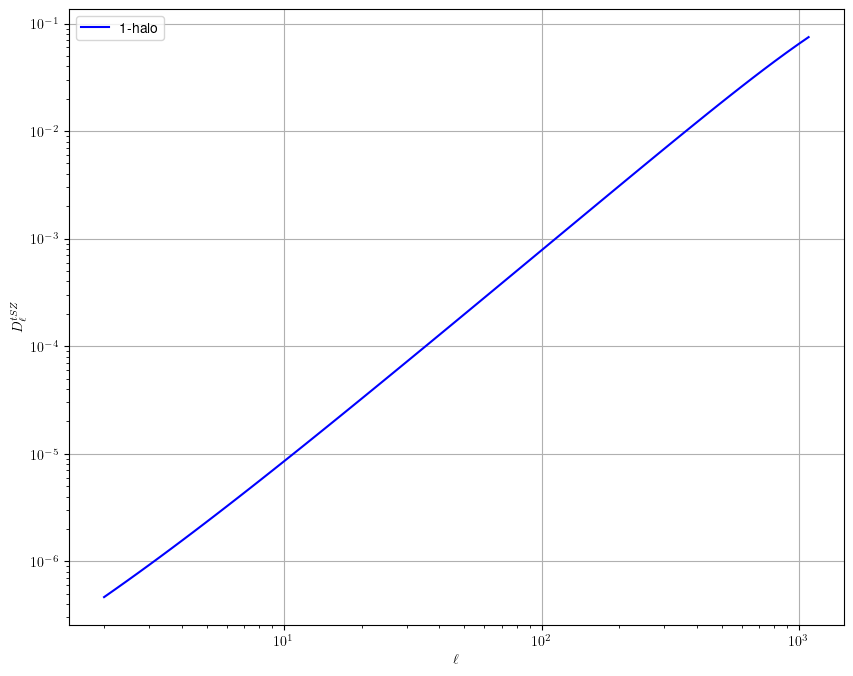

In [6]:
plt.figure(figsize=(10,8))
plt.loglog(l, cl_yy_1h, label='1-halo', color='blue')
# plt.loglog(l, cl_yy_2h, label='2-halo', color='red')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{tSZ}$')
plt.legend()
plt.grid()
plt.show()


# Using tszpower

In [7]:
allpars = {
    'omega_b': 0.02242,
    'omega_cdm':  0.1193,
    'H0': 67.66,
    'tau_reio': 0.0544,
    'ln10^{10}A_s': 2.972,
    # 'sigma8': 0.81,
    'n_s': 0.9665,
    "cosmo_model": 0, # 1: use mnu-lcdm emulators; 0: use lcdm with fixed neutrino mass
    "B": 1.41,

    'M_min': 1e14*0.6766,
    'M_max': 1e15*0.6766,

    'z_min' : 0.5,
    'z_max' : 3.0,

    "P0GNFW": 8.130,
    "c500": 1.156,
    "gammaGNFW": 0.3292,
    "alphaGNFW": 1.0620,
    "betaGNFW":5.4807,

    'jax' : 1, 
}
tsz.classy_sz.set(allpars)
tsz.initialise()

/var/folders/h0/4_tf3pcn1h32ks9grh325v400000gn/T/ipykernel_29304/657823160.py:27: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  tsz.initialise()


In [8]:
%%time
ell = tsz.get_ell_range()
D_ell_yy  = tsz.compute_Dell_yy(params_value_dict=allpars)

CPU times: user 2.41 s, sys: 326 ms, total: 2.73 s
Wall time: 1.04 s


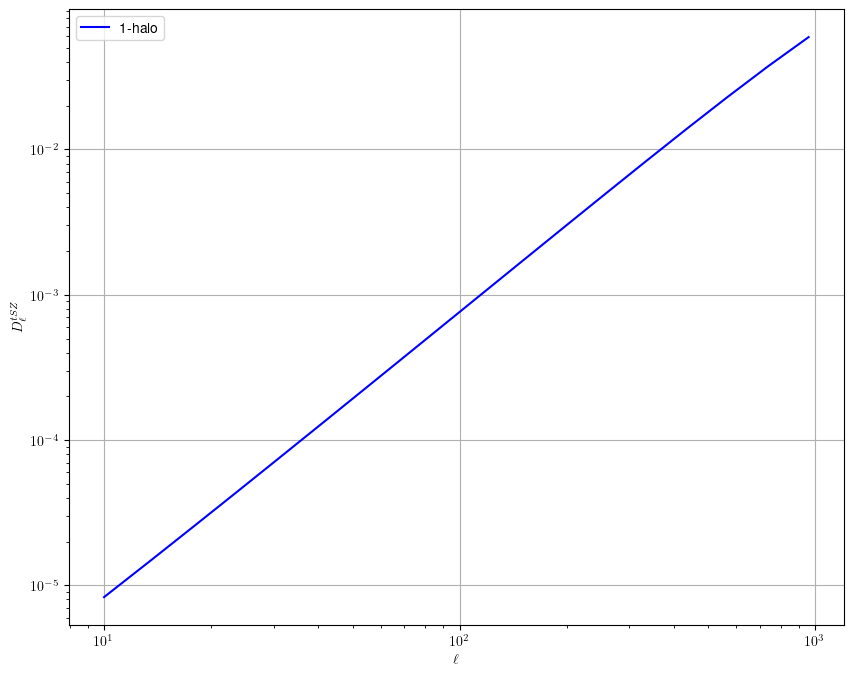

In [9]:
plt.figure(figsize=(10,8))
plt.loglog(ell, D_ell_yy, label='1-halo', color='blue')
# plt.loglog(l, cl_yy_2h, label='2-halo', color='red')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{tSZ}$')
plt.legend()
plt.grid()
plt.show()


# Compare tszpower with class_sz

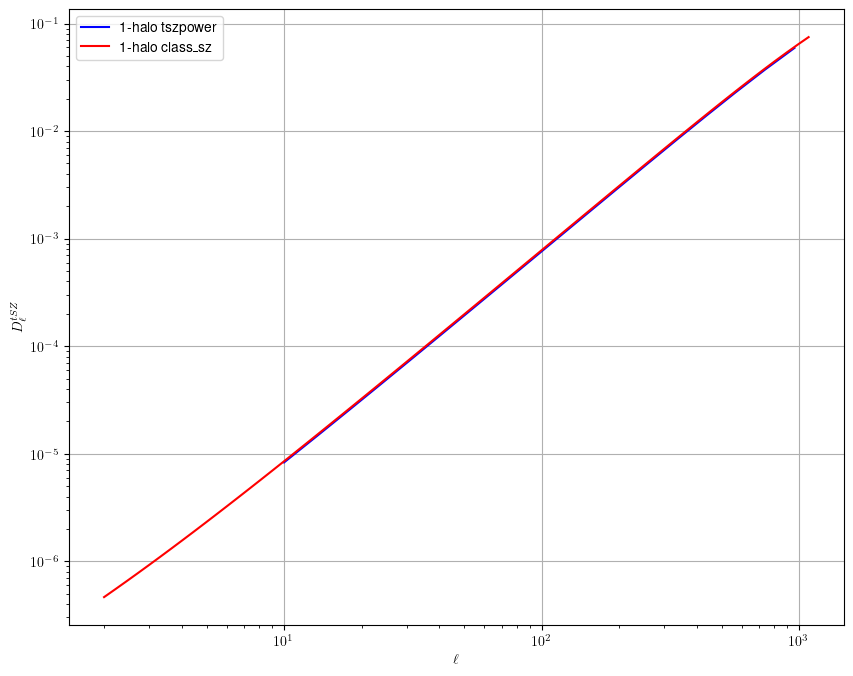

In [10]:
plt.figure(figsize=(10,8))
plt.loglog(ell, D_ell_yy, label='1-halo tszpower', color='blue')
plt.loglog(l, cl_yy_1h, label='1-halo class_sz', color='red')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{tSZ}$')
plt.legend()
plt.grid()
plt.show()


In [11]:
# Ratio:
# D_ell_yy/cl_yy_1h